# Project Pythia Notebook Template


```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

# Google Cloud CMIP6 Public Data: Spatial plots of total precipitation amount

**Derick Appiah Kubi** 

---

## Overview
This notebook uses query to load data from the Google Cloud CMIP6 catalog. It also goes on to;

1. Compute Monthly total Precipitation
2. Plots a timeseries for the mean of the total precipitation

## Prerequisites
This section was inspired by [CMIP6 Cookbook]( https://github.com/ProjectPythia/cmip6-cookbook) 



| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Total precipitation amount | Helpful | |

- **Time to learn**: 10 minutes

---

## Imports

In [124]:
import sys
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import fsspec
import nc_time_axis
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6

## Explore the collection
The catalog containing the data is saved as a CSV file, and it is loaded into Python using the Pandas library.

In [186]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


### Selecting the variable and the projection
Here I sample the data to select the monthly precipitation flux for historical experiment and the future scenario (SSP585).

In [187]:
df_ssp585 = df.query("activity_id=='ScenarioMIP' & table_id == 'Amon' & variable_id == 'pr' & experiment_id == 'ssp585'")  #future scenario
df_his = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'pr' & experiment_id == 'historical'")     #historical
print(df_his)
print(df_ssp585)

       activity_id       institution_id      source_id experiment_id  \
994           CMIP            NOAA-GFDL      GFDL-ESM4    historical   
1773          CMIP            NOAA-GFDL      GFDL-ESM4    historical   
6263          CMIP            NOAA-GFDL       GFDL-CM4    historical   
22128         CMIP                 IPSL   IPSL-CM6A-LR    historical   
22279         CMIP                 IPSL   IPSL-CM6A-LR    historical   
...            ...                  ...            ...           ...   
523412        CMIP                  MRI     MRI-ESM2-0    historical   
523675        CMIP                KIOST      KIOST-ESM    historical   
523713        CMIP                 CMCC   CMCC-CM2-SR5    historical   
523727        CMIP                 CMCC   CMCC-CM2-SR5    historical   
523766        CMIP  EC-Earth-Consortium  EC-Earth3-Veg    historical   

       member_id table_id variable_id grid_label  \
994     r3i1p1f1     Amon          pr        gr1   
1773    r2i1p1f1     Amon      

### Selection of the model for the future scenario
Further sampling is done to select the model I want to use from MPI-M.

In [127]:
df_pr_MPI = df_ssp585.query('institution_id == "MPI-M"')
df_pr_MPI.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
221806,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r7i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
221965,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r6i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
224170,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r9i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
224529,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r8i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
225410,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710


### Selection of the model for the historical experiment


In [155]:
df_pr_MPIhis = df_his.query('institution_id == "MPI-M"')
df_pr_MPIhis.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
222407,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710
223087,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710
223155,CMIP,MPI-M,MPI-ESM1-2-HR,historical,r3i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/hist...,NaN,20190710
223391,CMIP,MPI-M,MPI-ESM1-2-HR,historical,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/hist...,NaN,20190710
232875,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r5i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710


## Loading of the data
The data is loaded using fsspec, zarr and xarray from a single store.

In [156]:
# get the path to a specific zarr store (the first one from the dataframe above)
zstore = df_pr_MPI.zstore.values[7]
print(zstore)
zstorehis = df_pr_MPIhis.zstore.values[0]
print(zstorehis)

# create a mutable-mapping-style interface to the store
mapper = fsspec.get_mapper(zstore)
mapperhis = fsspec.get_mapper(zstorehis)

# open it using xarray and zarr
ds_ssp585 = xr.open_zarr(mapper, consolidated=True)
ds_his = xr.open_zarr(mapperhis, consolidated=True)

gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp585/r1i1p1f1/Amon/pr/gn/v20190710/
gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/v20190710/


### Calculating the total precipitation amount
In this section, the variable precipitation flux is selected from the data, the total precipitation amount is calculated and the unit is also changed

In [194]:
ds_pr_ssp585 = ds_ssp585['pr']    #selection of the variable precipitation flux
days = ds_pr_ssp585['time'].dt.days_in_month       #getting the right number of days from the data
ds_pr_ssp585 = ds_ssp585['pr'] * days * 86400         #calculating the total precipitation amount
ds_pr_ssp585.attrs['units'] = 'mm'                    # changing the unit from kg/m2/s to mm
ds_pr_ssp585.attrs['Long name'] = 'Total precipitation amount'          #redefining the long name
ds_pr_ssp585

<xarray.DataArray (time: 1032, lat: 96, lon: 192)> Size: 152MB
dask.array<mul, shape=(1032, 96, 192), dtype=float64, chunksize=(516, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    units:      mm
    Long name:  Total precipitation amount

The same process that was done for the future scenario is done for the historical experiment

In [195]:
ds_pr_his = ds_his['pr']
days = ds_pr_his['time'].dt.days_in_month
ds_pr_his = ds_his['pr']* days * 86400
ds_pr_his.attrs['units'] = 'mm'
ds_pr_his.attrs['Long name'] = 'Total precipitation amount'
ds_pr_his

<xarray.DataArray (time: 1980, lat: 96, lon: 192)> Size: 292MB
dask.array<mul, shape=(1980, 96, 192), dtype=float64, chunksize=(904, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    units:      mm
    Long name:  Total precipitation amount

### Selection of the study area and time

In [190]:
# For future scenario
ds_sa_ssp585 = ds_pr_ssp585.sel(lon=slice(-120 + 360, -20 + 360), lat=slice(-15, 25))  #Selecting the study area

years = ds_sa_ssp585['time'].dt.year
ds_2080_2100 = ds_sa_ssp585.where((years >= 2080) & (years <= 2100), drop=True)  # specifying the specific into the future I want to look at

mean_2080_2100 = ds_2080_2100.mean(dim='time')    # finding the mean at the time dimension


# For Historical
ds_sa_his = ds_pr_his.sel(lon=slice(-120 + 360, -20 + 360), lat=slice(-15, 25))    #study area selection

years = ds_sa_his['time'].dt.year
ds_1986_2005 = ds_sa_his.where((years >= 1986) & (years <= 2005), drop=True)   #subsetting the time

mean_1986_2005 = ds_1986_2005.mean(dim='time')  # time mean

### Plotting of the Total precipitation amount under SSP585

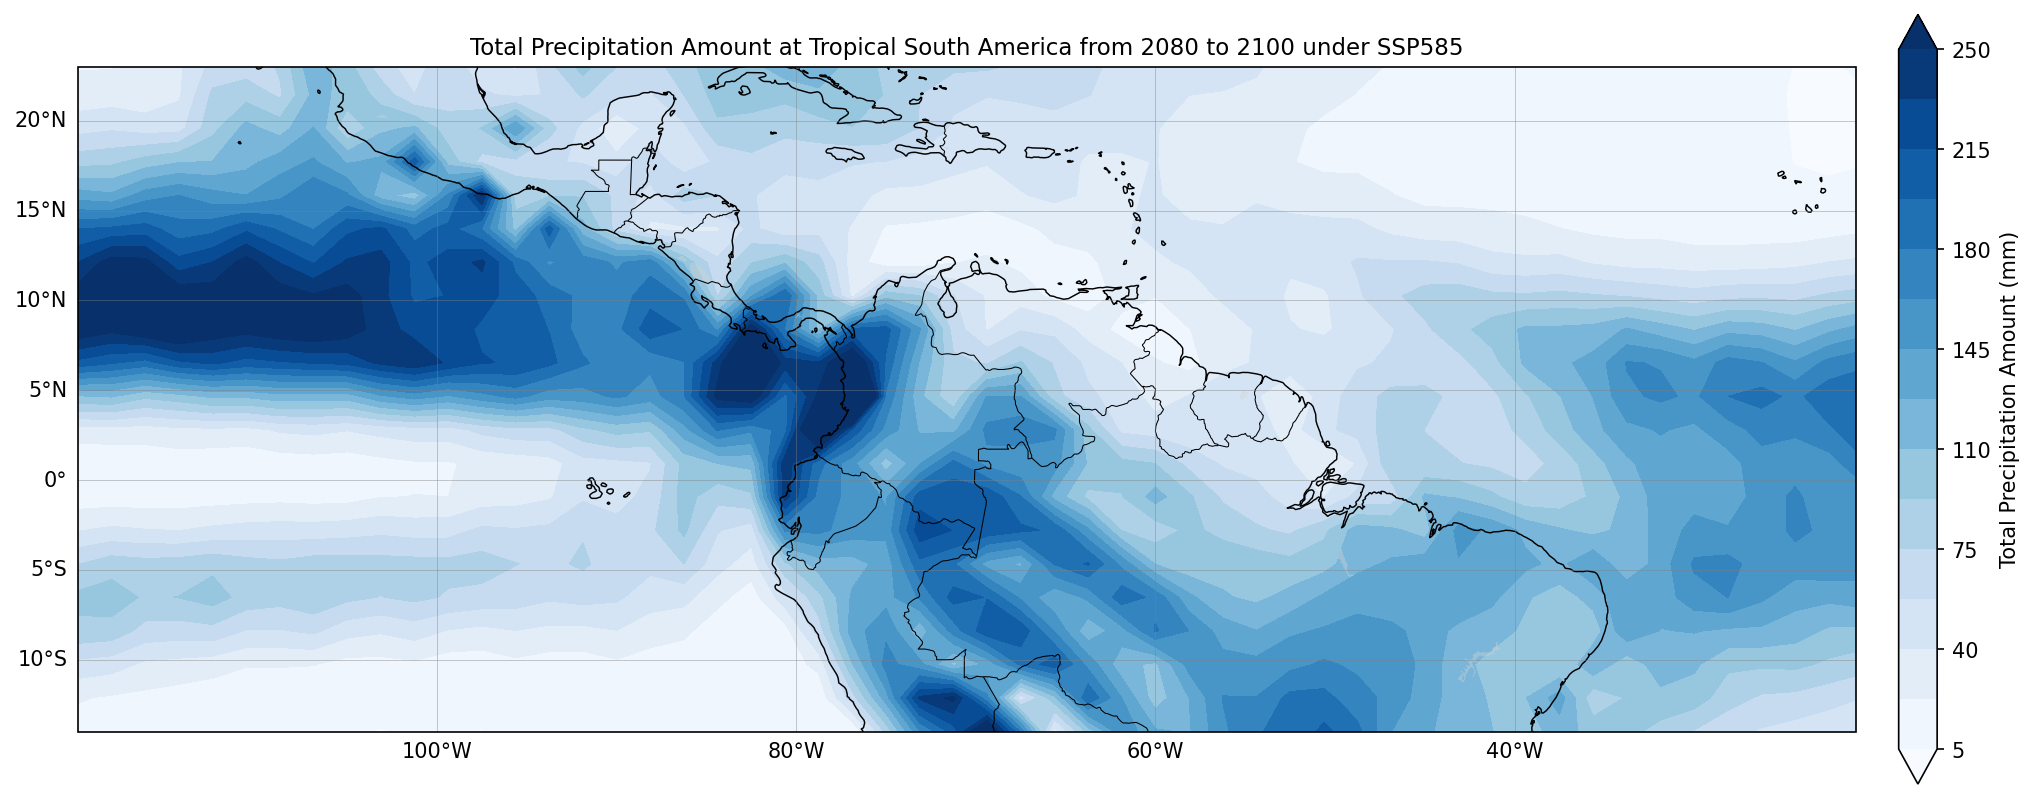

In [193]:
vmin = 5
vmax = 250
levels = np.linspace(vmin, vmax, 15)
fig = plt.figure(figsize=(15,6), dpi=150)
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)
ax.set_extent([-120 + 360, -21 + 360, -14, 23], crs=proj)
cf = ax.contourf(mean_2080_2100['lon'], mean_2080_2100['lat'], mean_2080_2100,
                 levels=levels, transform=proj, extend='both', cmap='Blues')
# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='-')
ax.add_feature(cfeature.LAKES, edgecolor='none', facecolor='lightgray', alpha=0.4)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# Colorbar + title
title = 'Total Precipitation Amount at Tropical South America from 2080 to 2100 under SSP585'
cb = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.9,label = 'Total Precipitation Amount (mm)')
ax.set_title(f'{title}', fontsize=11)
plt.tight_layout()
plt.show()


### Plotting of the Historical Total precipitation amount

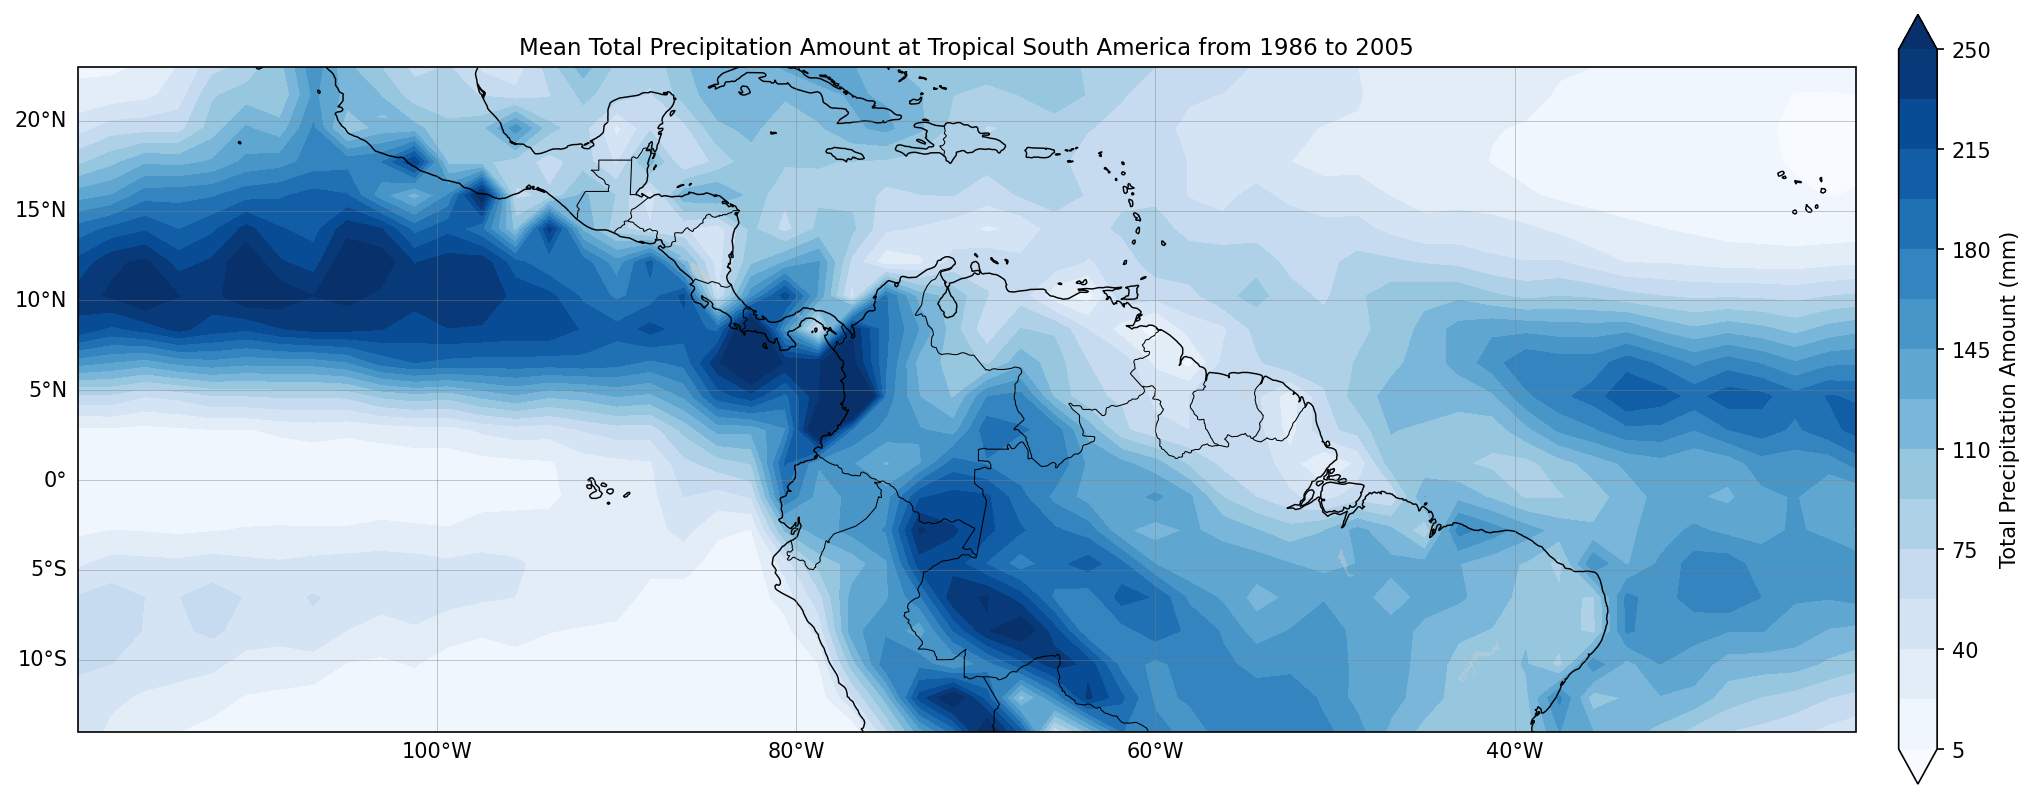

In [192]:
vmin = 5
vmax = 250
levels = np.linspace(vmin, vmax, 15)

# --- 4) Cartopy plot ---
fig = plt.figure(figsize=(15,6), dpi=150)
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)
ax.set_extent([-120 + 360, -21 + 360, -14, 23], crs=proj)

cf1 = ax.contourf(mean_1986_2005['lon'], mean_1986_2005['lat'], mean_1986_2005,
                 levels=levels, transform=proj, extend='both', cmap='Blues')
# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='-')
ax.add_feature(cfeature.LAKES, edgecolor='none', facecolor='lightgray', alpha=0.4)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# Colorbar + title
title = 'Mean Total Precipitation Amount at Tropical South America from 1986 to 2005'
cb = plt.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02, shrink=0.9, label = 'Total Precipitation Amount (mm)')
ax.set_title(f'{title}', fontsize=11)
plt.tight_layout()
plt.show()


## Summary
In this notebook, I opened a MPI-ESM1-2-LR dataset with fsspec and zarr. I calculated and made a spatial plot of historical and future scenario (ssp585) total precipitation amount.


## Resources and references
- [Original notebook in the Pangeo Gallery](http://gallery.pangeo.io/repos/pangeo-gallery/cmip6/ECS_Gregory_method.html) by Henri Drake and [Ryan Abernathey](https://ocean-transport.github.io/)